# Analise da Base de Dados *Video Game Sales* (vgsales)

**Disciplina:** Introducao a Ciencia de Dados - exercicio em grupo
**Dataset:** `gregorut/videogamesales` no Kaggle, acessado via `kagglehub`, com 16.598 jogos lancados entre 1980 e 2020 e vendas globais e regionais (em **milhoes de unidades**).

## Sobre a base
A base reúne informações de jogos eletrônicos comercializados no mundo todo. Para cada jogo temos:

| Coluna | Descrição |
|---|---|
| `Rank` | Posição global do jogo em vendas |
| `Name` | Nome do jogo |
| `Platform` | Console / plataforma (Wii, PS2, X360, PC, ...) |
| `Year` | Ano de lançamento |
| `Genre` | Gênero (Action, Sports, Shooter, RPG, ...) |
| `Publisher` | Empresa publicadora |
| `NA_Sales` | Vendas na América do Norte (milhões) |
| `EU_Sales` | Vendas na Europa (milhões) |
| `JP_Sales` | Vendas no Japão (milhões) |
| `Other_Sales` | Vendas em outras regiões (milhões) |
| `Global_Sales` | Vendas globais (milhões) |

## Objetivo do trabalho
Formular **7 perguntas** sobre a base e respondê-las com **7 gráficos**, explicando para cada uma:
- **O que** a pergunta investiga
- **Como** o gráfico foi construído (transformações aplicadas)
- **O que** o gráfico mostra (interpretação dos resultados)


## Configuracao inicial - carregando bibliotecas e dados

> Se necessario, instale antes: `pip install kagglehub`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from pathlib import Path

# Estilo visual padrao para todos os graficos
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

# Baixa a versao mais recente do dataset no cache local do KaggleHub
dataset_path = Path(kagglehub.dataset_download("gregorut/videogamesales"))

# Carrega o CSV baixado
df = pd.read_csv(dataset_path / "vgsales.csv")

print(f"Total de jogos: {len(df):,}")
print(f"Período: {int(df['Year'].min())} a {int(df['Year'].max())}")
print(f"Plataformas distintas: {df['Platform'].nunique()}")
print(f"Gêneros distintos: {df['Genre'].nunique()}")
print(f"Publishers distintos: {df['Publisher'].nunique()}")
print(f"Vendas globais totais: {df['Global_Sales'].sum():,.0f} milhões de unidades")

df.head()

Total de jogos: 16,598
Período: 1980 a 2020
Plataformas distintas: 31
Gêneros distintos: 12
Publishers distintos: 578
Vendas globais totais: 8,920 milhões de unidades


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


### Tratamento de dados ausentes
O dataset tem alguns valores nulos em `Year` (271 linhas) e `Publisher` (58 linhas). Mantemos o dataset completo e filtramos os nulos apenas nas perguntas em que essas colunas são usadas.

In [2]:
print("Valores nulos por coluna:")
print(df.isna().sum())

Valores nulos por coluna:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


---
## Pergunta 1 — Quais são os 10 jogos mais vendidos globalmente de todos os tempos?

**O que queremos descobrir:** identificar os títulos que mais venderam unidades no mundo todo desde 1980. Isso nos dá uma noção de quais jogos foram fenômenos culturais e comerciais.

**Como o gráfico foi construído:**
- Ordenamos a base pela coluna `Global_Sales` em ordem decrescente.
- Selecionamos as 10 primeiras linhas.
- Plotamos um **gráfico de barras horizontal**, com o nome do jogo no eixo Y e as vendas globais no eixo X. Barras horizontais são melhores que verticais quando os rótulos (nomes de jogos) são longos.

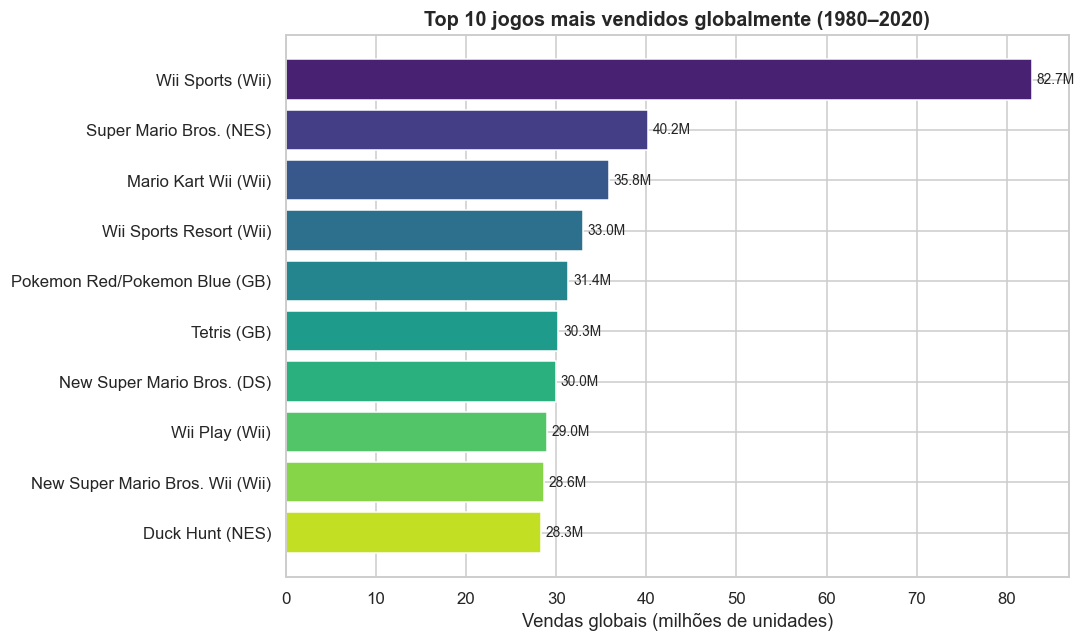

,Name,Platform,Global_Sales
0,Wii Sports,Wii,82.74
1,Super Mario Bros.,NES,40.24
2,Mario Kart Wii,Wii,35.82
3,Wii Sports Resort,Wii,33.00
4,Pokemon Red/Pokemon Blue,GB,31.37
5,Tetris,GB,30.26
6,New Super Mario Bros.,DS,30.01
7,Wii Play,Wii,29.02
8,New Super Mario Bros. Wii,Wii,28.62
9,Duck Hunt,NES,28.31


In [3]:
top10_jogos = df.nlargest(10, "Global_Sales")[["Name", "Platform", "Global_Sales"]]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    top10_jogos["Name"] + " (" + top10_jogos["Platform"] + ")",
    top10_jogos["Global_Sales"],
    color=sns.color_palette("viridis", 10),
)
ax.invert_yaxis()  # maior no topo
ax.set_xlabel("Vendas globais (milhões de unidades)")
ax.set_title("Top 10 jogos mais vendidos globalmente (1980–2020)")

# Rótulo no fim de cada barra
for bar, valor in zip(bars, top10_jogos["Global_Sales"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{valor:.1f}M", va="center", fontsize=9)

plt.tight_layout()
plt.show()

top10_jogos

**O que o gráfico mostra:**
- **Wii Sports** lidera disparado com mais de 82 milhões de cópias — em grande parte porque vinha *junto* com o console Wii, ampliando muito a base instalada.
- A **Nintendo domina o top 10**: praticamente todos os jogos são da empresa (Mario, Wii, Pokémon, Tetris).
- A maioria dos campeões está em plataformas Nintendo (Wii, NES, DS, GB). Os únicos "intrusos" costumam ser GTA V e Tetris.
- Conclusão: títulos de plataforma Nintendo, especialmente os "first-party" (desenvolvidos pela própria Nintendo), têm um poder de venda histórico difícil de igualar.

---
## Pergunta 2 — Qual gênero de jogo gera mais vendas globais?

**O que queremos descobrir:** entender quais gêneros (Action, Sports, RPG etc.) são os mais lucrativos em volume de vendas mundiais. Isso ajuda a entender o gosto médio do mercado global.

**Como o gráfico foi construído:**
- Agrupamos os jogos por `Genre` e somamos `Global_Sales` de cada grupo.
- Ordenamos do maior para o menor.
- Plotamos um **gráfico de barras vertical** com paleta sequencial — barras mais altas em cores mais quentes para reforçar a ordem.

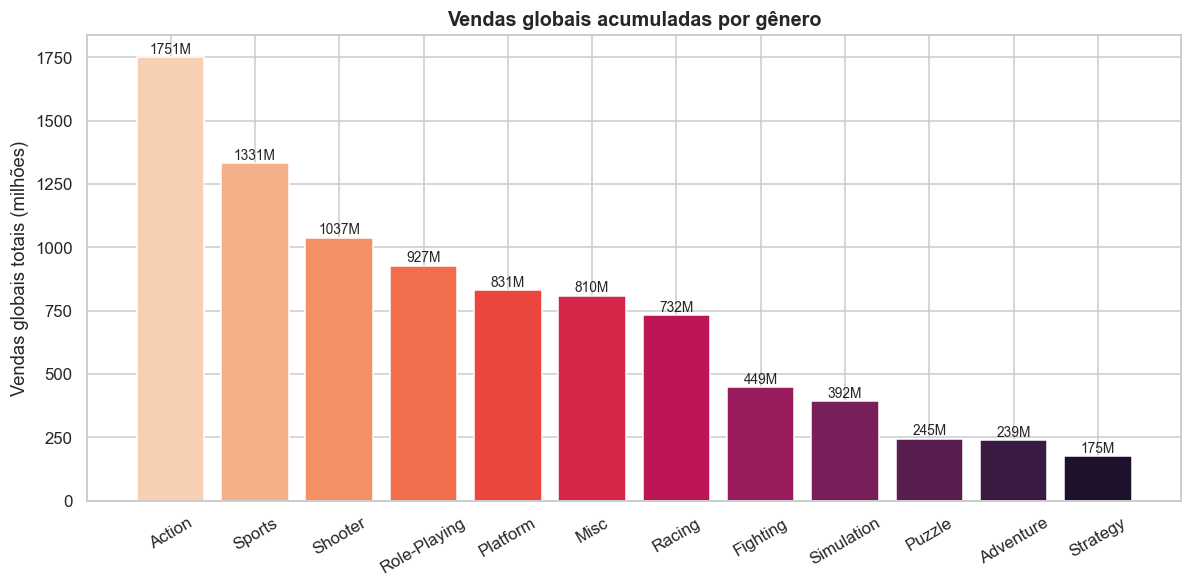

Genre
Action          1751.2
Sports          1330.9
Shooter         1037.4
Role-Playing     927.4
Platform         831.4
Misc             810.0
Racing           732.0
Fighting         448.9
Simulation       392.2
Puzzle           245.0
Adventure        239.0
Strategy         175.1
Name: Global_Sales, dtype: float64

In [4]:
vendas_genero = (
    df.groupby("Genre")["Global_Sales"]
      .sum()
      .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(11, 5.5))
cores = sns.color_palette("rocket_r", len(vendas_genero))
bars = ax.bar(vendas_genero.index, vendas_genero.values, color=cores)

ax.set_ylabel("Vendas globais totais (milhões)")
ax.set_title("Vendas globais acumuladas por gênero")
ax.tick_params(axis="x", rotation=30)

for bar, valor in zip(bars, vendas_genero.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f"{valor:.0f}M", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

vendas_genero.round(1)

**O que o gráfico mostra:**
- **Action** é o gênero líder absoluto, somando mais de 1,7 bilhão de unidades — quase o dobro do segundo colocado.
- **Sports** e **Shooter** vêm logo atrás, formando o "top 3" que concentra grande parte do faturamento da indústria.
- Gêneros como **Puzzle**, **Adventure** e **Strategy** vendem muito menos em volume — não significa que sejam menos importantes, mas que atendem nichos menores.
- A indústria recompensa fortemente jogos de ação rápida e jogos esportivos com lançamentos anuais (FIFA, NBA, Madden).

---
## Pergunta 3 — Como o mercado de jogos evoluiu ao longo dos anos?

**O que queremos descobrir:** identificar a evolução temporal das vendas. Quando o mercado bombou? Quando esfriou? Existe alguma tendência clara?

**Como o gráfico foi construído:**
- Removemos linhas sem `Year` definido.
- Agrupamos por ano e somamos as `Global_Sales`.
- Plotamos um **gráfico de linha com área preenchida**, que evidencia bem a evolução cumulativa ano a ano.
- Destacamos o ano de pico com um marcador.

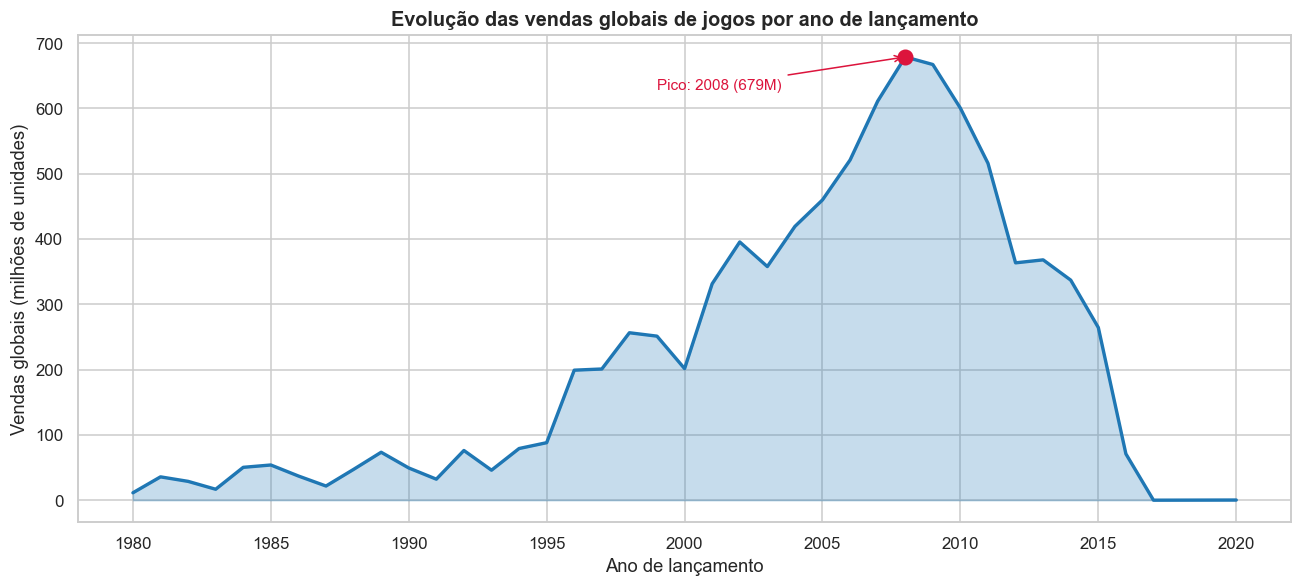

Year
2004.0    419.3
2005.0    459.9
2006.0    521.0
2007.0    611.1
2008.0    678.9
2009.0    667.3
2010.0    600.4
2011.0    516.0
2012.0    363.5
2013.0    368.1
2014.0    337.0
2015.0    264.4
2016.0     70.9
2017.0      0.0
2020.0      0.3
Name: Global_Sales, dtype: float64

In [5]:
vendas_ano = (
    df.dropna(subset=["Year"])
      .groupby("Year")["Global_Sales"]
      .sum()
      .sort_index()
)

ano_pico = vendas_ano.idxmax()
valor_pico = vendas_ano.max()

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.fill_between(vendas_ano.index, vendas_ano.values, alpha=0.25, color="#1f77b4")
ax.plot(vendas_ano.index, vendas_ano.values, color="#1f77b4", linewidth=2.2)

ax.scatter([ano_pico], [valor_pico], color="crimson", s=90, zorder=5)
ax.annotate(
    f"Pico: {int(ano_pico)} ({valor_pico:.0f}M)",
    xy=(ano_pico, valor_pico),
    xytext=(ano_pico - 9, valor_pico - 50),
    fontsize=10, color="crimson",
    arrowprops=dict(arrowstyle="->", color="crimson"),
)

ax.set_xlabel("Ano de lançamento")
ax.set_ylabel("Vendas globais (milhões de unidades)")
ax.set_title("Evolução das vendas globais de jogos por ano de lançamento")
plt.tight_layout()
plt.show()

vendas_ano.tail(15).round(1)

**O que o gráfico mostra:**
- O mercado cresceu de forma lenta nos anos 80–90 e **explodiu entre 2000 e 2010**, com pico em **2008–2009** (era de ouro do Wii, PS3, Xbox 360 e Nintendo DS).
- Após 2010 há uma queda acentuada. **Atenção:** isso *não* significa que a indústria diminuiu — a base coleta apenas vendas físicas registradas, e a partir de 2013–2016 boa parte das vendas migrou para **digital** (Steam, PSN, eShop), que não aparece aqui. Os dados de 2017+ também estão **incompletos** no dataset.
- Mesmo com essa limitação, fica claro o "boom" da sétima geração de consoles como o momento mais intenso de vendas físicas da história.

---
## Pergunta 4 — Quais plataformas (consoles) dominaram historicamente o mercado?

**O que queremos descobrir:** descobrir quais consoles concentraram mais vendas ao longo da história — uma medida indireta do sucesso comercial de cada plataforma.

**Como o gráfico foi construído:**
- Agrupamos por `Platform` e somamos `Global_Sales`.
- Pegamos as 10 plataformas com maior volume.
- Plotamos **barras verticais** com paleta que diferencia plataformas Nintendo, Sony, Microsoft e PC pelas cores.

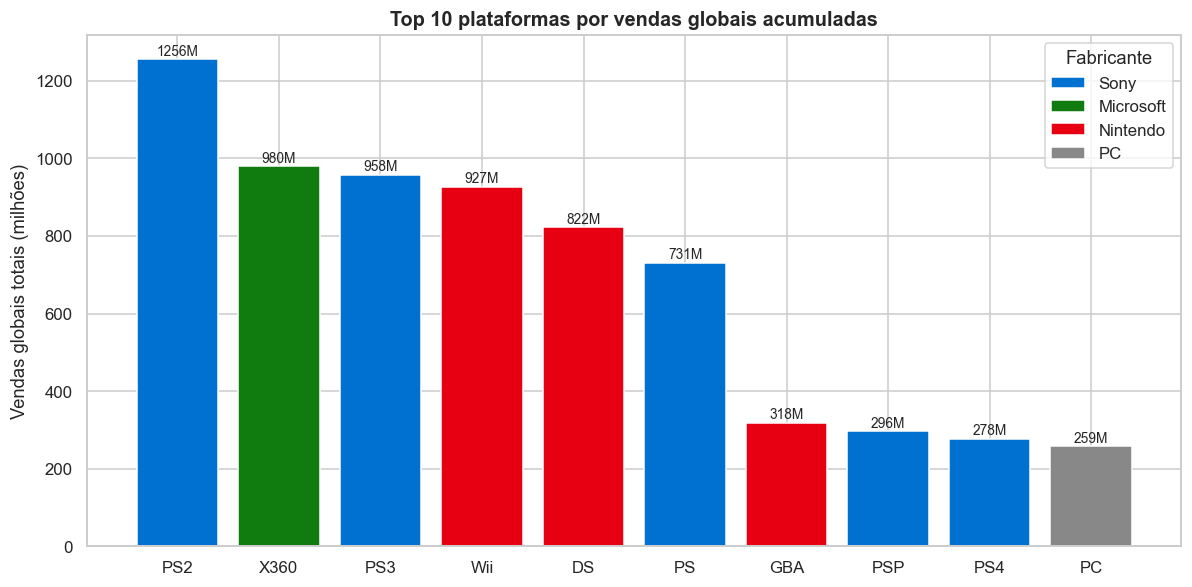

Platform
PS2     1255.6
X360     980.0
PS3      957.8
Wii      926.7
DS       822.5
PS       730.7
GBA      318.5
PSP      296.3
PS4      278.1
PC       258.8
Name: Global_Sales, dtype: float64

In [6]:
vendas_plataforma = (
    df.groupby("Platform")["Global_Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

# Coloração por fabricante
fabricante = {
    "PS2": "Sony", "PS3": "Sony", "PS": "Sony", "PS4": "Sony", "PSP": "Sony",
    "X360": "Microsoft", "XB": "Microsoft", "XOne": "Microsoft",
    "Wii": "Nintendo", "DS": "Nintendo", "GBA": "Nintendo", "GB": "Nintendo",
    "3DS": "Nintendo", "NES": "Nintendo", "SNES": "Nintendo", "N64": "Nintendo",
    "GC": "Nintendo", "WiiU": "Nintendo",
    "PC": "PC",
}
cor_fab = {"Sony": "#0070D1", "Microsoft": "#107C10",
           "Nintendo": "#E60012", "PC": "#888888"}

cores = [cor_fab.get(fabricante.get(p, "PC"), "#888888")
         for p in vendas_plataforma.index]

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(vendas_plataforma.index, vendas_plataforma.values, color=cores)
ax.set_ylabel("Vendas globais totais (milhões)")
ax.set_title("Top 10 plataformas por vendas globais acumuladas")

for bar, valor in zip(bars, vendas_plataforma.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f"{valor:.0f}M", ha="center", fontsize=9)

# Legenda manual por fabricante
from matplotlib.patches import Patch
legendas = [Patch(facecolor=cor, label=fab) for fab, cor in cor_fab.items()]
ax.legend(handles=legendas, title="Fabricante", loc="upper right")

plt.tight_layout()
plt.show()

vendas_plataforma.round(1)

**O que o gráfico mostra:**
- O **PlayStation 2** é o líder histórico de vendas — sozinho ele acumula mais de 1,2 bilhão de unidades vendidas.
- O top 10 é dividido principalmente entre **Sony** (azul) e **Nintendo** (vermelho), com a **Microsoft** (verde) aparecendo com X360 e o **PC** (cinza) tendo presença residual no físico (jogos de PC vendem majoritariamente em digital).
- Consoles portáteis (DS, GBA, PSP) aparecem fortemente no ranking, mostrando que o portátil teve um peso enorme na indústria — algo que perdeu força com a chegada dos smartphones.

---
## Pergunta 5 — Como as vendas se distribuem entre as regiões do mundo?

**O que queremos descobrir:** entender o peso de cada mercado regional (América do Norte, Europa, Japão e demais regiões) na indústria global.

**Como o gráfico foi construído:**
- Somamos cada coluna regional (`NA_Sales`, `EU_Sales`, `JP_Sales`, `Other_Sales`).
- Plotamos um **gráfico de rosca (donut chart)** — uma variação do gráfico de pizza, mais limpa visualmente e que destaca melhor as proporções.
- Adicionamos os valores absolutos e percentuais.

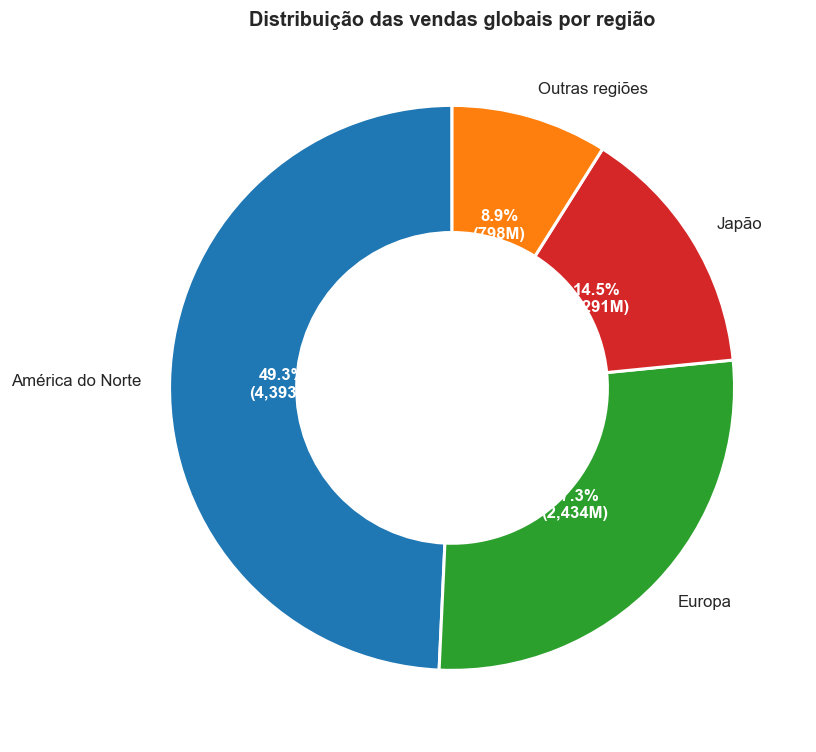

América do Norte    4393.0
Europa              2434.1
Japão               1291.0
Outras regiões       797.8
dtype: float64

In [7]:
vendas_regiao = pd.Series({
    "América do Norte": df["NA_Sales"].sum(),
    "Europa":           df["EU_Sales"].sum(),
    "Japão":            df["JP_Sales"].sum(),
    "Outras regiões":   df["Other_Sales"].sum(),
}).sort_values(ascending=False)

cores = ["#1f77b4", "#2ca02c", "#d62728", "#ff7f0e"]

fig, ax = plt.subplots(figsize=(8, 7))
wedges, texts, autotexts = ax.pie(
    vendas_regiao.values,
    labels=vendas_regiao.index,
    autopct=lambda p: f"{p:.1f}%\n({p*vendas_regiao.sum()/100:,.0f}M)",
    startangle=90,
    colors=cores,
    wedgeprops=dict(width=0.45, edgecolor="white", linewidth=2),
    textprops=dict(fontsize=11),
)
for t in autotexts:
    t.set_color("white"); t.set_fontweight("bold")

ax.set_title("Distribuição das vendas globais por região")
plt.tight_layout()
plt.show()

vendas_regiao.round(1)

**O que o gráfico mostra:**
- A **América do Norte** sozinha responde por cerca de **49%** das vendas mundiais — é, de longe, o maior mercado consumidor da indústria.
- A **Europa** é o segundo maior mercado (~27%), com peso bem maior que o **Japão** (~15%), apesar do Japão ser o berço cultural dos videogames.
- "Outras regiões" (~9%) incluem América Latina, Oceania, Ásia (fora Japão) e África — mercados em crescimento, mas ainda pequenos em vendas físicas.
- Para uma desenvolvedora pensar em lançamento global, ignorar América do Norte é praticamente inviável; ignorar Japão é mais aceitável (a menos que o gênero seja RPG).

---
## Pergunta 6 — Quais publishers (publicadoras) lideram em vendas globais?

**O que queremos descobrir:** identificar as empresas que mais venderam jogos ao longo da história. Isso revela o "tamanho" das gigantes do setor.

**Como o gráfico foi construído:**
- Removemos as linhas com `Publisher` ausente.
- Agrupamos por `Publisher`, somamos `Global_Sales` e pegamos as 10 maiores.
- Plotamos **barras horizontais** com gradiente de cor — facilita comparar empresas com nomes longos.

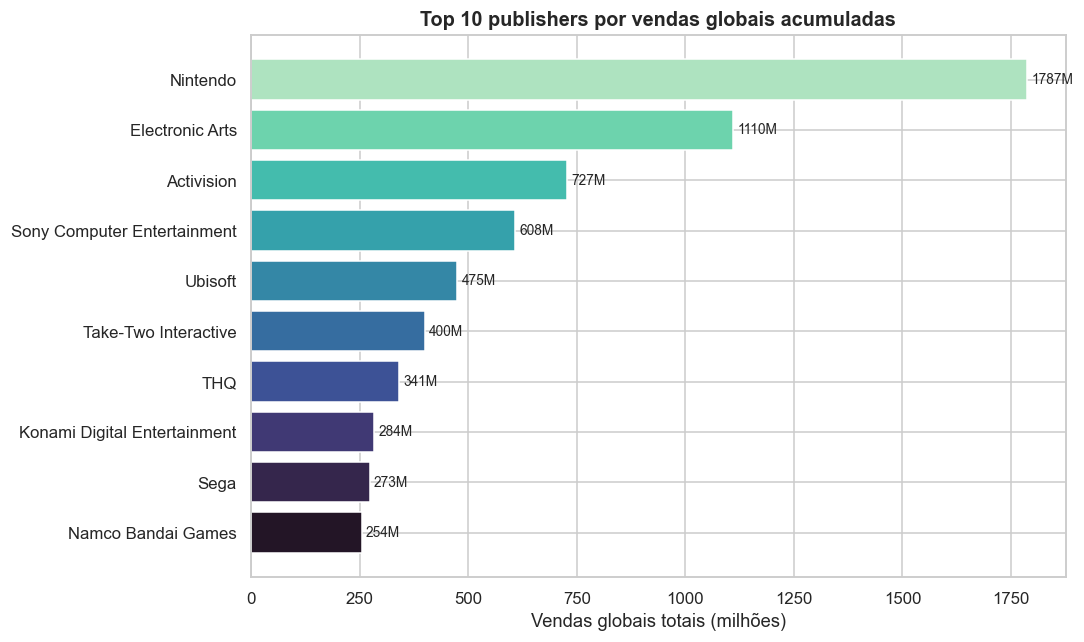

Publisher
Nintendo                        1786.6
Electronic Arts                 1110.3
Activision                       727.5
Sony Computer Entertainment      607.5
Ubisoft                          474.7
Take-Two Interactive             399.5
THQ                              340.8
Konami Digital Entertainment     283.6
Sega                             273.0
Namco Bandai Games               254.1
Name: Global_Sales, dtype: float64

In [8]:
vendas_publisher = (
    df.dropna(subset=["Publisher"])
      .groupby("Publisher")["Global_Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

fig, ax = plt.subplots(figsize=(10, 6))
cores = sns.color_palette("mako_r", 10)
bars = ax.barh(vendas_publisher.index, vendas_publisher.values, color=cores)
ax.invert_yaxis()
ax.set_xlabel("Vendas globais totais (milhões)")
ax.set_title("Top 10 publishers por vendas globais acumuladas")

for bar, valor in zip(bars, vendas_publisher.values):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f"{valor:.0f}M", va="center", fontsize=9)

plt.tight_layout()
plt.show()

vendas_publisher.round(1)

**O que o gráfico mostra:**
- A **Nintendo** é a líder absoluta, vendendo mais que o dobro da segunda colocada — consequência de ela publicar exclusivamente seus próprios consoles com franquias monumentais (Mario, Pokémon, Zelda, Wii Sports).
- **Electronic Arts (EA)**, **Activision** e **Sony Computer Entertainment** formam o segundo bloco, sustentados por franquias multiplataforma (FIFA, Call of Duty, Uncharted).
- Publishers japonesas (**Konami, Sega, Capcom, Square Enix, Namco**) aparecem fortemente, mostrando o peso histórico do Japão como produtor (mesmo não sendo o maior consumidor).
- **Ubisoft** é a única europeia no top 10 — mostrando que a publicação global é dominada por americanas e japonesas.

---
## Pergunta 7 — Cada região do mundo prefere um gênero diferente?

**O que queremos descobrir:** comparar o gosto regional. Será que Japão consome os mesmos tipos de jogo que América do Norte? A indústria precisa adaptar lançamentos por região?

**Como o gráfico foi construído:**
- Agrupamos por `Genre` e somamos as vendas em cada região (NA, EU, JP, Other).
- Para cada região, calculamos o **percentual** que cada gênero representa do total daquela região (normalização por coluna). Isso permite comparar "preferências" em pé de igualdade, mesmo que o tamanho dos mercados seja diferente.
- Plotamos um **heatmap** (mapa de calor): linhas = gêneros, colunas = regiões, cor = % do mercado regional. Quanto mais escura a célula, maior a preferência daquela região por aquele gênero.

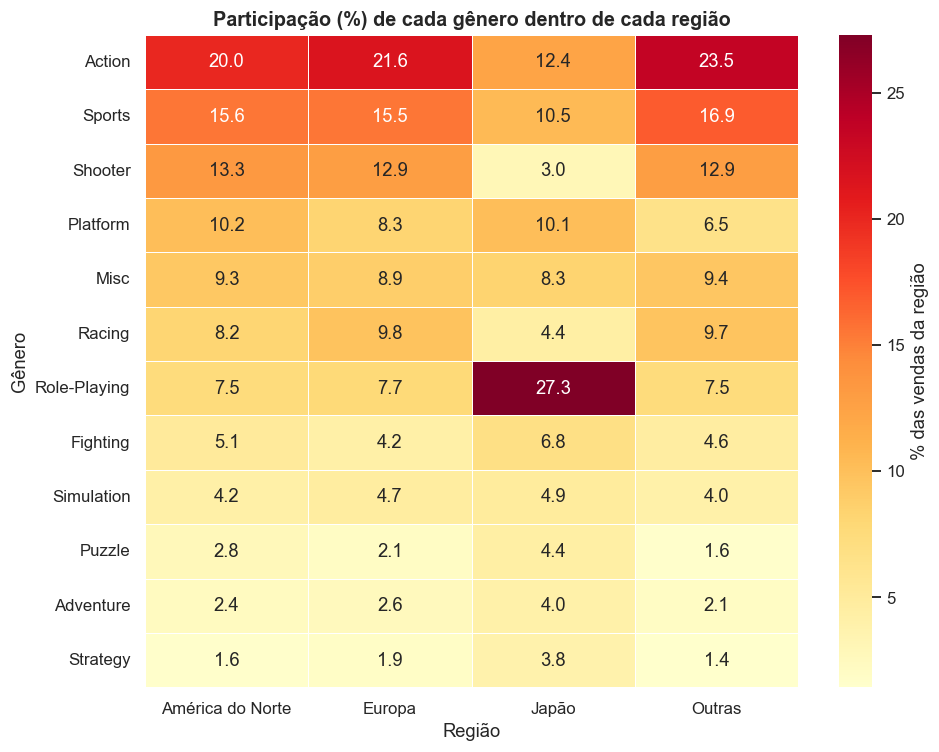

,América do Norte,Europa,Japão,Outras
Genre,,,,
Action,20.0,21.6,12.4,23.5
Sports,15.6,15.5,10.5,16.9
Shooter,13.3,12.9,3.0,12.9
Platform,10.2,8.3,10.1,6.5
Misc,9.3,8.9,8.3,9.4
Racing,8.2,9.8,4.4,9.7
Role-Playing,7.5,7.7,27.3,7.5
Fighting,5.1,4.2,6.8,4.6
Simulation,4.2,4.7,4.9,4.0


In [9]:
regioes = {
    "NA_Sales": "América do Norte",
    "EU_Sales": "Europa",
    "JP_Sales": "Japão",
    "Other_Sales": "Outras",
}

vendas_genero_regiao = df.groupby("Genre")[list(regioes.keys())].sum()
vendas_genero_regiao = vendas_genero_regiao.rename(columns=regioes)

# Normaliza por coluna -> % do mercado regional
percentual = vendas_genero_regiao.div(vendas_genero_regiao.sum(axis=0), axis=1) * 100
percentual = percentual.sort_values("América do Norte", ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    percentual, annot=True, fmt=".1f", cmap="YlOrRd",
    cbar_kws={"label": "% das vendas da região"},
    linewidths=0.4, linecolor="white", ax=ax,
)
ax.set_title("Participação (%) de cada gênero dentro de cada região")
ax.set_xlabel("Região")
ax.set_ylabel("Gênero")
plt.tight_layout()
plt.show()

percentual.round(1)

**O que o gráfico mostra:**
- **América do Norte e Europa** têm gostos muito parecidos: dominados por **Action, Sports e Shooter**. O "ocidente" é o mercado dos blockbusters de tiro e esporte.
- **Japão é um caso à parte**: o gênero mais consumido lá é **Role-Playing (RPG)**, com porcentagem muito acima das outras regiões — é o mercado natural de Final Fantasy, Pokémon, Dragon Quest e Persona.
- **Shooter** vende muito bem no Ocidente (NA + EU) mas tem participação modesta no Japão — uma diferença cultural marcante.
- Gêneros como **Platform** e **Fighting** também têm presença relativamente maior no Japão.
- **Conclusão estratégica:** quem quer vender no Japão deve apostar em RPG; quem quer vender no Ocidente aposta em Ação, Esporte e Tiro. A indústria realmente precisa pensar em "regionalização" do portfólio.

---
## Conclusões gerais

A partir das 7 perguntas, conseguimos um retrato completo do mercado de jogos físicos entre 1980 e 2016:

1. **Quem vende mais (jogos):** títulos da Nintendo, especialmente os que vêm "junto" com o console (Wii Sports é o caso extremo).
2. **O que vende mais (gênero):** Action, Sports e Shooter — a "santíssima trindade" da indústria.
3. **Quando vendeu mais:** auge entre **2008 e 2009**, com a sétima geração de consoles. A queda após 2010 reflete a transição para o **digital**, não a morte do mercado.
4. **Onde vende mais (plataforma):** PlayStation 2 é o campeão histórico, seguido por consoles Nintendo (DS, Wii) e Xbox 360.
5. **Onde vende mais (região):** América do Norte concentra praticamente metade das vendas globais.
6. **Quem publica mais:** Nintendo lidera com folga, seguida por gigantes americanas (EA, Activision) e japonesas (Konami, Sega, Capcom).
7. **Gostos por região:** Ocidente prefere Action/Sports/Shooter; Japão prefere RPG. Estratégias de lançamento devem se adaptar a essa diferença.

### Limitações da base
- Cobre apenas **vendas físicas** — a partir de meados dos anos 2010, o digital domina e não está representado.
- Os dados de 2017–2020 estão incompletos.
- Não inclui mobile (iOS/Android), que hoje é o maior segmento da indústria.

Mesmo com essas limitações, o dataset é riquíssimo para estudar a história e a geografia da indústria de games antes da era digital plena.
